# General notebook

In [68]:
using Revise
Revise.retry() # Just in case if only Revise is not sufficient. 
include("lattice_protein.jl")

Imports done, importing hamiltonian path
hamiltonian path imported, importing metropolis
metropolis imported, importing benchmark
benchmark imported, importing visualization
visualization imported, importing tree
tree imported, importing lattice_protein


## Hamiltonian paths

In [2]:
println("We find $(length(PATHS)) unique paths.")
println(first(PATHS))

We find 103346 unique paths.
Int8[1, 2, 3, 6, 5, 4, 7, 8, 9, 18, 17, 16, 13, 14, 15, 12, 11, 10, 19, 20, 21, 24, 23, 22, 25, 26, 27]


Contact map for the first path:
Path visualization for the 75005:


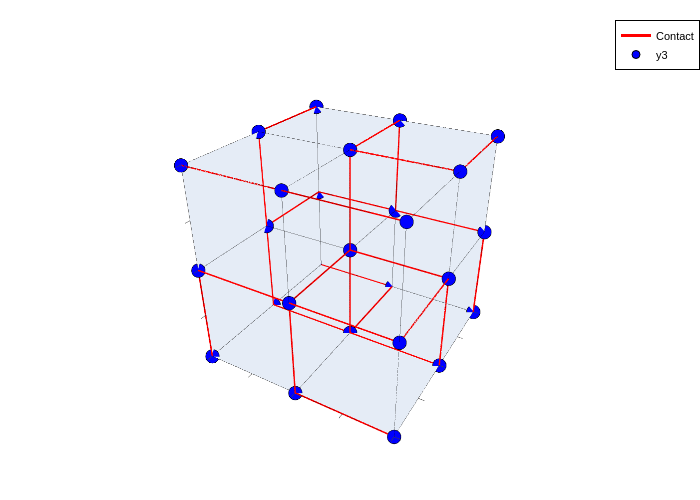

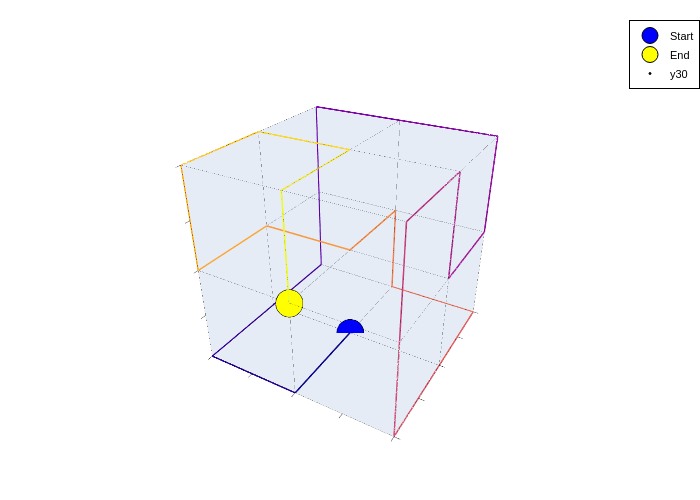

In [3]:
println("Contact map for the first path:")
liste_contact = contact_map(PATHS[75005])
display(plot_cube_ctc_map(x, y, z, lx, ly, lz, liste_contact))

println("Path visualization for the 75005:")
display(plot_cube_path(x, y, z, lx, ly, lz, PATHS[75005]))

## Metropolis general results

Attention : si on veut changer de matrice (MJ*5 ou MJ_1996) il faut restart le kernel et modifier la ligne const dans le ficher metropolis.jl. 

MJ*5

algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:42


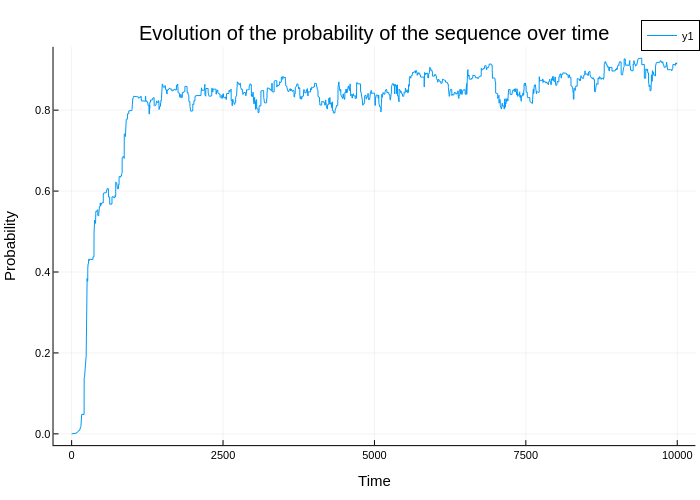

In [4]:
# with all the data
seq = generate_seq()
print(matrix_name)
target_number = 75005
all_ctc_maps = all_contact_maps(PATHS)
plot_probability(seq, target_number, all_ctc_maps, 10000)

MJ*5

algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:04


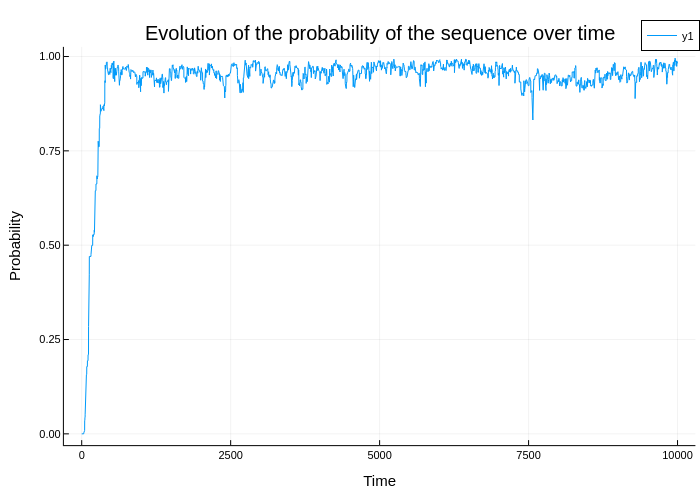

In [5]:
# with few data
paths_reduced = reduce_data(PATHS, 10)
seq = generate_seq()
target_number = 1234
print(matrix_name)

all_ctc_maps = all_contact_maps(paths_reduced)
plot_probability(seq, target_number, all_ctc_maps, 10000)

Testing beta = 10


algo (β=10) 100%|████████████████████████████████████████| Time: 0:00:01


Testing beta = 50


algo (β=50) 100%|████████████████████████████████████████| Time: 0:00:01


Testing beta = 100


algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:01


Testing beta = 1000


algo (β=1000) 100%|██████████████████████████████████████| Time: 0:00:02


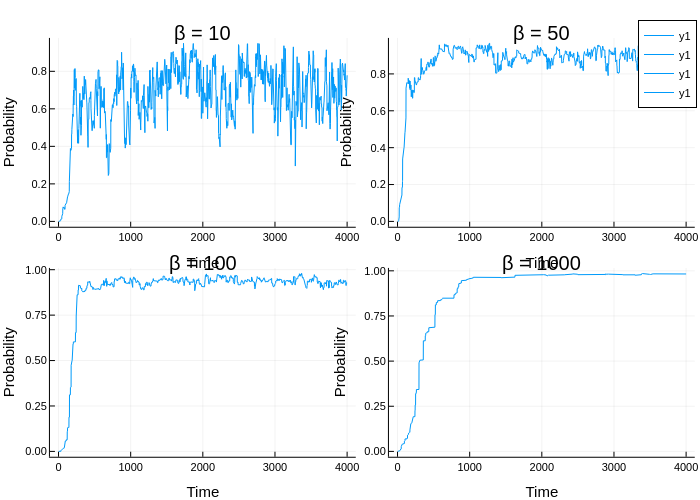

Dict{Float64, Tuple{Vector{Int64}, Vector{Float64}}} with 4 entries:
  50.0   => ([8, 16, 6, 5, 15, 19, 5, 13, 3, 16  …  4, 11, 16, 18, 3, 19, 19, 3…
  10.0   => ([4, 20, 9, 10, 16, 20, 12, 13, 15, 20  …  19, 16, 15, 14, 2, 19, 4…
  1000.0 => ([8, 17, 6, 2, 15, 19, 2, 19, 5, 16  …  6, 18, 19, 16, 1, 15, 10, 1…
  100.0  => ([17, 20, 18, 16, 2, 16, 19, 10, 5, 1  …  5, 1, 16, 19, 18, 19, 18,…

In [6]:
paths_reduced = reduce_data(PATHS, 10)
seq = generate_seq()
target_number = 1234
all_ctc_maps = all_contact_maps(paths_reduced)


benchmark_beta()

## Further observations

### Chain evolution

ici

Multi-init 100%|█████████████████████████████████████████| Time: 0:00:13


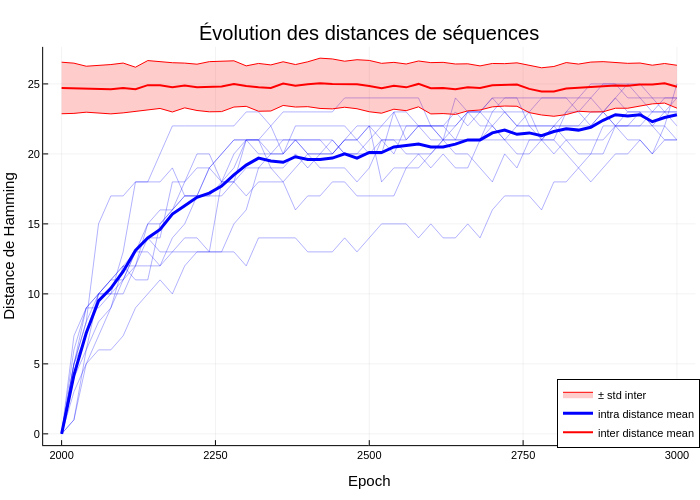

In [7]:
paths_reduced = reduce_data(PATHS, 10)
beta = 100.0

seq_over_time = multi_init_seq_over_time(target_number, all_ctc_maps, epochs=3000, beta=beta, threshold=2000, step=20, runs=10)
plot_distances_inter_intra(seq_over_time, beta=beta)

### All proba

In [8]:
final_seq, p_struct_time_t, p_final,_=algo_show_probability_distribution(seq, target_number, all_ctc_maps, 10000, 100)
show_sorted_indices(p_final)

algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:04


structure 1234 : 0.9757759413317105
structure 1233 : 0.005949058619026937
structure 1558 : 0.0032649125939274094
structure 529 : 0.0021885363602637533
structure 493 : 0.0019802695894988926
structure 2332 : 0.001542235506994228
structure 557 : 0.0008897924833223624
structure 5032 : 0.0008051175331972071
structure 1797 : 0.0006929710827825086
structure 496 : 0.0005396864219168708
structure 517 : 0.000488328468556316
structure 5033 : 0.0003441192556622157
structure 1777 : 0.00028174101733695843
structure 1235 : 0.0002680003457796848
structure 1785 : 0.00026800034577968213
structure 570 : 0.00024249674090803336
structure 1236 : 0.00021942012492535992
structure 3085 : 0.00019853953930258923
structure 1237 : 0.0001625504265289635
structure 3103 : 0.0001546227486794933


In [9]:
# Mutations en fonction de la position
paths_reduced = reduce_data(PATHS, 10)
seq = generate_seq()
target_number = 1234

all_ctc_maps = all_contact_maps(paths_reduced)

beta = 100

_, _, saved_seq = algo(seq, target_number, all_ctc_maps, 10000, beta, 2000, 200)
println("On a sauvegardé $(length(saved_seq)) structures.")

n_mutations_per_position = amount_of_mutations(saved_seq)
n_mutations_per_position


algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:03


On a sauvegardé 41 structures.


Dict{Int64, Int64} with 27 entries:
  5  => 16
  16 => 16
  20 => 13
  12 => 39
  24 => 28
  8  => 19
  17 => 11
  1  => 36
  23 => 13
  22 => 20
  19 => 27
  6  => 33
  11 => 30
  9  => 7
  14 => 18
  3  => 36
  7  => 27
  25 => 18
  4  => 20
  ⋮  => ⋮

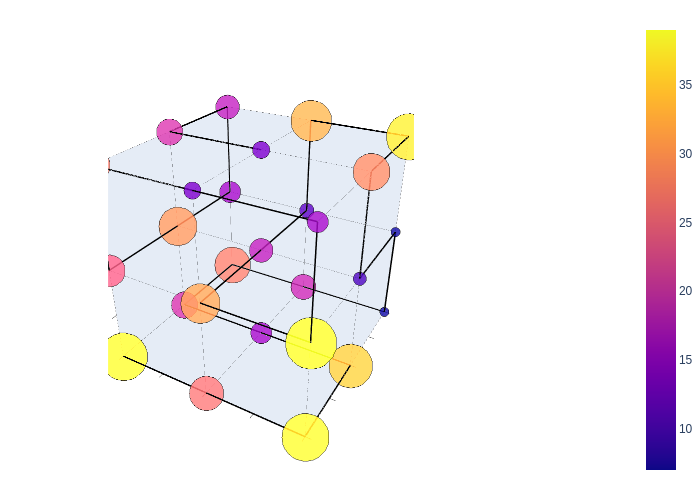

In [10]:
plot_cube_with_mutations_on_sphere(x, y, z, lx, ly, lz, PATHS[1234], n_mutations_per_position)

## Tree generation

In [69]:
paths_reduced = reduce_data(PATHS, 10)
seq = generate_seq()
target_number = 1234
all_ctc_maps = all_contact_maps(paths_reduced)
beta = 100

root_seq,p_struct_time_t,_ = algo(seq, target_number, all_ctc_maps, 5000, beta, 10000, 200, true)
proba_final_root = p_struct_time_t[end]
println(proba_final_root)

newick, seq_dict = create_genealogy(root_seq, 50, 2, target_number, all_ctc_maps, beta=100 )

println(newick)

# Charger l'arbre dans TreeTools
tree = parse_newick_string(newick)

for node in nodes(tree)
    name = label(node)
    println("$name : " * join([aa_idx[acid] for acid in seq_dict[name]], " "))
end

algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:02


0.9511161259117181
((N3:50,N4:50)N2:50,(N6:50,N7:50)N5:50)N1;
N3 : GLU LYS TRP GLU ASP THR LYS CYS ASP ASP LEU MET ILE LEU CYS ILE ASP LYS GLN ASN LYS ILE ASN CYS ILE LYS GLY
N4 : GLY ASP ASP GLU ASP LEU LYS LEU ASP ASP MET LYS VAL PHE VAL ILE ASP ARG TYR GLU LYS ILE ASN VAL PHE THR MET
N5 : ASN SER PRO GLU ASP MET ARG LEU ASP LYS PHE TYR VAL MET ILE LEU ASN ARG GLU THR ASP ILE ASN VAL VAL ARG CYS
N7 : LEU SER GLY GLU ASP MET ARG THR ASP ASN LEU GLU TYR VAL LEU LEU ASP HIS GLU ASP ASP ILE ARG MET VAL PRO ILE
N1 : TYR ASN VAL GLU ASP TRP ARG ASN ASP ASP ILE VAL PHE LEU TRP LEU ASP LYS GLU THR ASP ILE ASN VAL VAL GLY MET
N6 : ASN ASN LEU GLU ASP ALA LYS PRO ASP GLY LEU GLY LEU CYS LEU ILE ASN ARG GLY LYS GLU PHE GLY VAL PHE ASP CYS
N2 : HIS ASN CYS GLU ASP PHE LYS LYS ASP ASN VAL ILE CYS LEU VAL LEU ASP LYS THR ASN LYS ILE ASN LEU VAL ASN MET


In [70]:
simple_print_distance_matrix(seq_dict)

      N3    N4    N5    N7    N1    N6    N2    
N3    0     17    22    21    18    21    16    
N4    17    0     18    22    18    19    17    
N5    22    18    0     16    15    19    20    
N7    21    22    16    0     17    22    19    
N1    18    18    15    17    0     22    15    
N6    21    19    19    22    22    0     22    
N2    16    17    20    19    15    22    0     


In [71]:
p = plot_distance_matrix(seq_dict)
savefig(p, "../figures/distance_matrix.svg")

"/home/gabriel/Documents/S2/Projet_BIM/pBIM/figures/distance_matrix.svg"

In [72]:
tree


                                        _____________________________________ N3
  _____________________________________|
 |                                     |_____________________________________ N4
_|
 |                                      _____________________________________ N6
 |_____________________________________|
                                       |_____________________________________ N7


In [73]:
result = fitch_reconstruction(tree, seq_dict)

for (name, seq) in sort(collect(result))
    println("$name : " * join([aa_idx[acid] for acid in seq], " "))
end

N1 : LEU ASP LEU GLU ASP LEU LYS LEU ASP ASP LEU GLU LEU LEU LEU ILE ASP ARG GLN GLU GLU ILE GLY VAL PHE ASP ILE
N2 : GLU ASP ASP GLU ASP LEU LYS LEU ASP ASP LEU MET ILE LEU VAL ILE ASP ARG GLN GLU LYS ILE ASN VAL PHE THR MET
N3 : GLU LYS TRP GLU ASP THR LYS CYS ASP ASP LEU MET ILE LEU CYS ILE ASP LYS GLN ASN LYS ILE ASN CYS ILE LYS GLY
N4 : GLY ASP ASP GLU ASP LEU LYS LEU ASP ASP MET LYS VAL PHE VAL ILE ASP ARG TYR GLU LYS ILE ASN VAL PHE THR MET
N5 : LEU SER LEU GLU ASP MET LYS PRO ASP GLY LEU GLU LEU VAL LEU ILE ASP ARG GLU ASP GLU ILE GLY VAL PHE ASP ILE
N6 : ASN ASN LEU GLU ASP ALA LYS PRO ASP GLY LEU GLY LEU CYS LEU ILE ASN ARG GLY LYS GLU PHE GLY VAL PHE ASP CYS
N7 : LEU SER GLY GLU ASP MET ARG THR ASP ASN LEU GLU TYR VAL LEU LEU ASP HIS GLU ASP ASP ILE ARG MET VAL PRO ILE


In [74]:
root_name_reconstructed, root_seq_reconstructed = first(sort(collect(result)))

"N1" => [5, 16, 5, 15, 16, 5, 19, 5, 16, 16  …  18, 13, 15, 15, 4, 10, 6, 3, 16, 4]

In [75]:
reconstruction_error_hamming(result, seq_dict)

7.571428571428571

algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:02


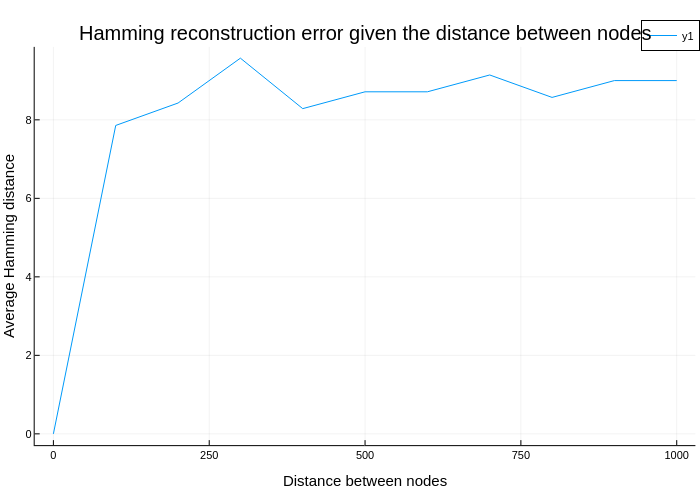

In [76]:
distance_btw_nodes = 0:100:1000
paths_reduced = reduce_data(PATHS, 10)
seq = generate_seq()
target_number = 1234
all_ctc_maps = all_contact_maps(paths_reduced)
number_of_nodes = 2

root_seq,_,_ = algo(seq, target_number, all_ctc_maps, 5000, 100, 10000, 200, true)

plot_reconstruction_error_hamming(root_seq, distance_btw_nodes, number_of_nodes, target_number, all_ctc_maps, beta=100)

In [77]:
reconstruction_error_prob_folding(result, seq_dict, all_ctc_maps, target_number)

-0.020589938990561003

algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:01


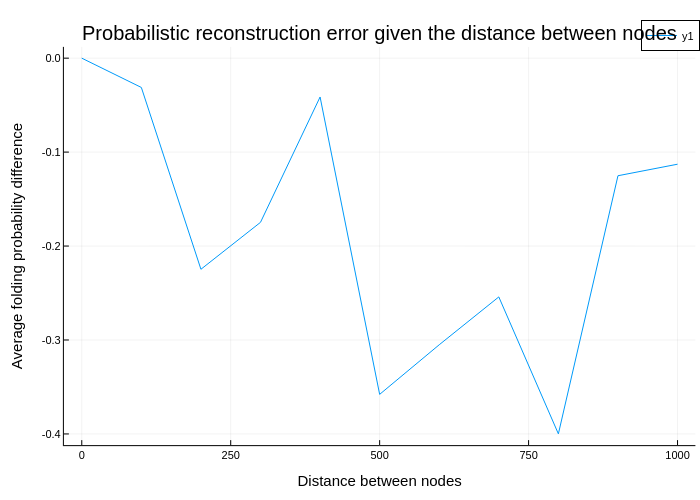

In [78]:
distance_btw_nodes = 0:100:1000
paths_reduced = reduce_data(PATHS, 10)
seq = generate_seq()
target_number = 1234
all_ctc_maps = all_contact_maps(paths_reduced)
number_of_nodes = 2

root_seq,_,_ = algo(seq, target_number, all_ctc_maps, 5000, 100, 10000, 200, true)

plot_reconstruction_error_proba(root_seq, distance_btw_nodes, number_of_nodes, target_number, all_ctc_maps, beta=100)